Accuracy: 0.7
              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.80      0.67      0.73         6

    accuracy                           0.70        10
   macro avg       0.70      0.71      0.70        10
weighted avg       0.72      0.70      0.70        10

Saved tree image.


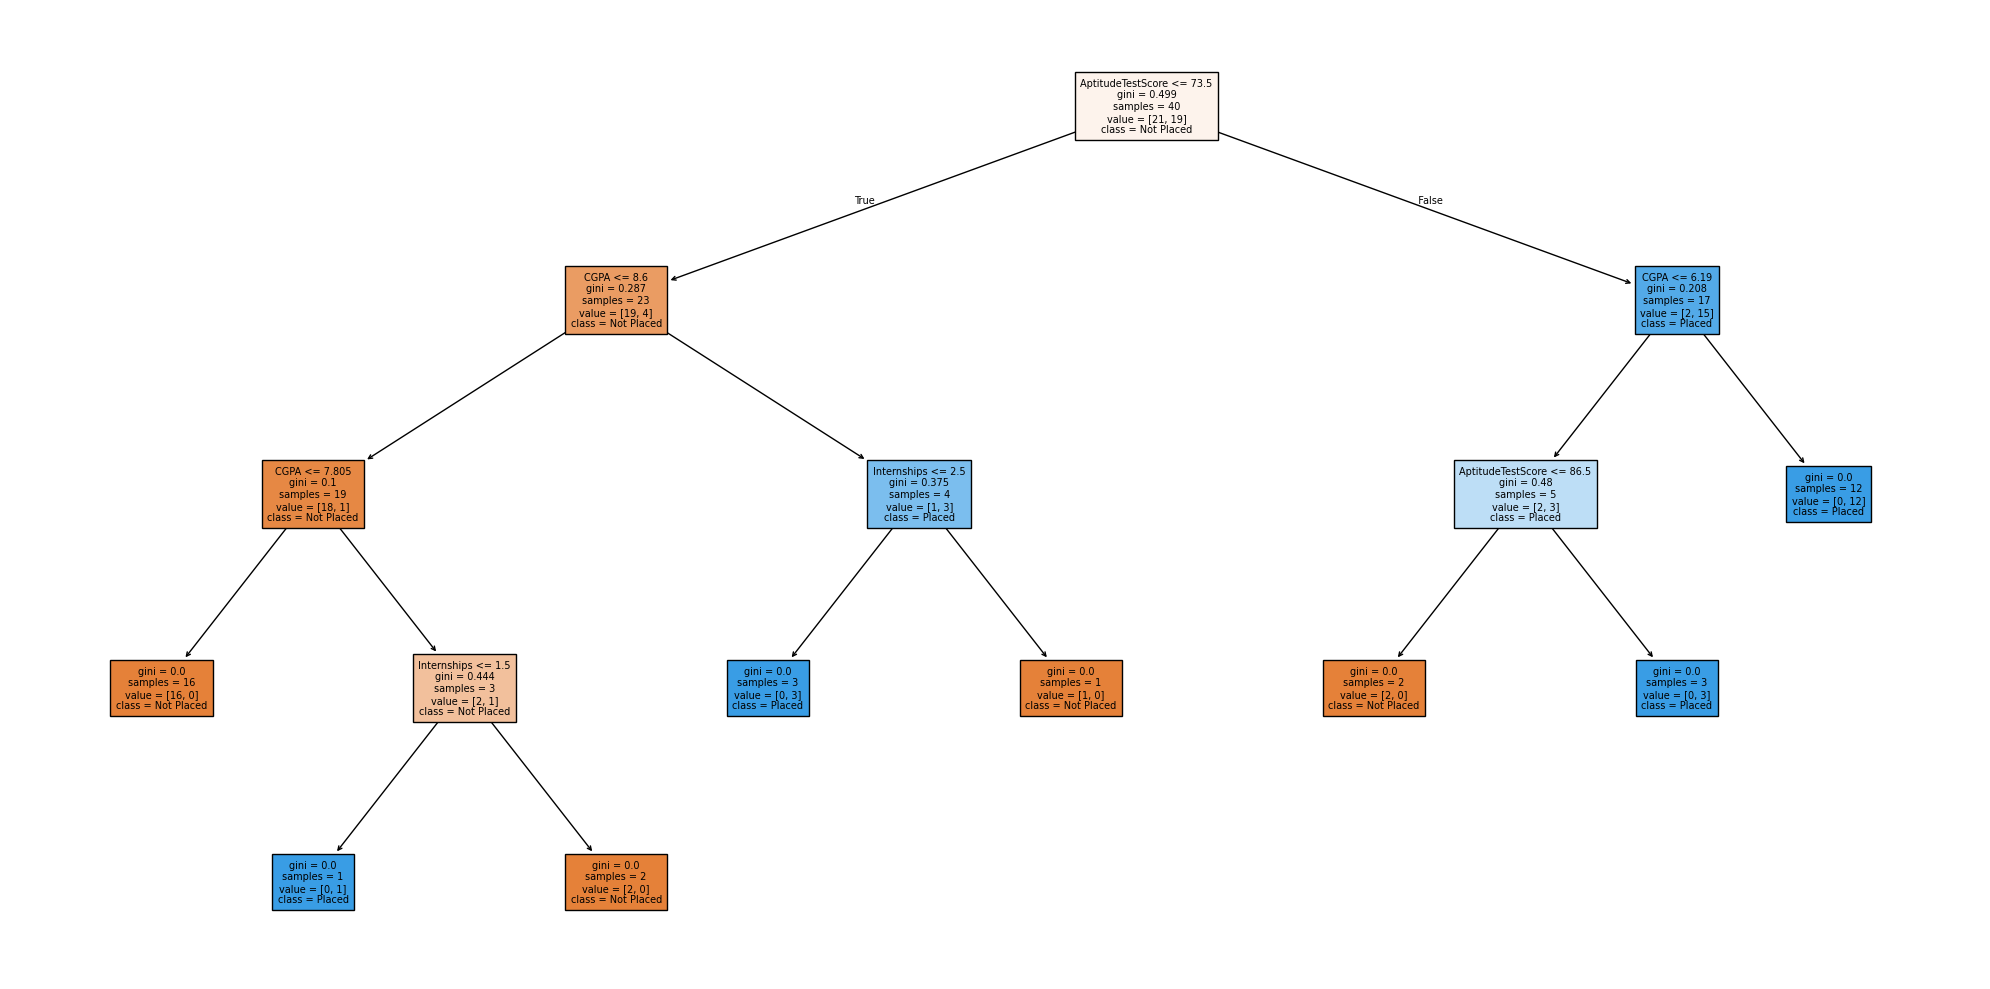

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

df = pd.read_csv('simple_placement_dataset.csv')

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

categorical_cols_to_encode = [
    'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation',
    'Hostel', 'HistoryOfBacklogs', 'ExtraCurricular'
]

existing_categorical_cols = [col for col in categorical_cols_to_encode if col in df.columns]

df_encoded = pd.get_dummies(df, columns=existing_categorical_cols, drop_first=True)

X = df_encoded.drop(columns=['Placed', 'StudentID'])
y = df_encoded['Placed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=['Not Placed', 'Placed'], filled=True, fontsize=7)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150)
print("Saved tree image.")